# LAPORAN PRAKTIKUM PENGOLAHAN CITRA DAN VISI KOMPUTER (PCVK)
## MINGGU 1: PENGENALAN CITRA DIGITAL & MANIPULASI BENTUK GEOMETRI (KTM)

### Identitas Kelompok: **KELOMPOK 7**
**Anggota Kelompok:**
1. **Nawaf Azril Annaufal** (NIM: `244107020047`) &rarr; Citra: `KTM_ALDY.jpeg`
2. **Afrizal Rafli Kusuma Wardana** (NIM: `244107020007`) &rarr; Citra: `KTM_RIZAL.jpeg`
3. **Tri Aldy Kurniawan** (NIM: `244107020098`) &rarr; Citra: `KTM_TRIALDY.jpeg`

**Program Studi / Jurusan:** D-IV Teknik Informatika / Teknologi Informasi  
**Institusi:** Politeknik Negeri Malang  

---

### Deskripsi Tugas Praktikum:
1. **Akses Citra Lokal:** Membaca ketiga file citra KTM lokal anggota kelompok menggunakan pustaka **OpenCV** (`cv2.imread`), mengonversi format warna dari BGR ke RGB (`cv2.cvtColor`), memeriksa informasi teknis citra (resolusi spasial, kanal warna, ukuran file), dan menampilkannya menggunakan **Matplotlib**.
2. **Menutup / Membingkai Bagian Tertentu (Kelompok 7):** Sesuai ketentuan pembagian tugas untuk **Kelompok 7**, dilakukan penutupan/pembingkaian pada 3 area tertentu:
   - **Tulisan "Politeknik Negeri Malang"**
   - **Logo BNI**
   - **Bagian "Program Studi D-IV TEKNIK INFORMATIKA"**  
   *Catatan Desain:* Bentuk penutupan dibuat **hollow / outline dengan bagian tengah transparan** (`thickness > 0`), dikreasikan dengan variasi bentuk geometri (`cv2.rectangle`, `cv2.ellipse`), ukuran yang proporsional, serta palet warna yang harmonis dan kontras.


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi kualitas render visualisasi
plt.rcParams['figure.dpi'] = 120

# Menentukan lokasi direktori citra secara dinamis agar fleksibel
possible_dirs = [
    '.',
    'WEEK 1/Kelompok',
    'Kelompok',
    os.path.join('..', 'Kelompok'),
    os.path.join('..', '..', 'WEEK 1', 'Kelompok')
]

base_dir = '.'
for d in possible_dirs:
    if os.path.exists(os.path.join(d, 'KTM_ALDY.jpeg')):
        base_dir = d
        break

print(f"Direktori aset citra KTM ditemukan di: '{os.path.abspath(base_dir)}'")


Direktori aset citra KTM ditemukan di: 'c:\Users\rizal\Documents\PCVK_GANJIL-2026\WEEK 1\Kelompok'


---
## Tugas 1: Membaca dan Memeriksa Informasi Citra Digital

Pada tahap ini, ketiga file citra KTM anggota kelompok dibaca menggunakan fungsi `cv2.imread()`. 
Secara default, OpenCV memuat citra dalam urutan kanal warna **BGR** (Blue, Green, Red). Agar warna citra tampil akurat pada pustaka **Matplotlib**, kita mengonversinya ke format standar **RGB** (Red, Green, Blue) menggunakan fungsi `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.


In [2]:
def baca_dan_info_citra(nama_file):
    """
    Membaca citra dengan OpenCV, mengonversi BGR ke RGB,
    dan mengekstraksi informasi teknis citra (resolusi, kanal, ukuran file).
    """
    path_file = os.path.join(base_dir, nama_file)
    
    # 1. Membaca citra menggunakan OpenCV (format bawaan: BGR)
    img_bgr = cv2.imread(path_file)
    if img_bgr is None:
        raise FileNotFoundError(f"File citra tidak ditemukan di {path_file}")
        
    # 2. Konversi format BGR ke RGB untuk visualisasi Matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 3. Ekstraksi dimensi spasial citra
    tinggi, lebar, kanal = img_rgb.shape
    total_piksel = tinggi * lebar
    
    # 4. Menghitung ukuran file dalam disk (Bytes, KB, MB)
    ukuran_bytes = os.path.getsize(path_file)
    ukuran_kb = ukuran_bytes / 1024
    ukuran_mb = ukuran_kb / 1024
    
    return {
        "nama_file": nama_file,
        "path": path_file,
        "img_bgr": img_bgr,
        "img_rgb": img_rgb,
        "lebar": lebar,
        "tinggi": tinggi,
        "kanal": kanal,
        "dtype": img_rgb.dtype,
        "total_piksel": total_piksel,
        "ukuran_bytes": ukuran_bytes,
        "ukuran_kb": ukuran_kb,
        "ukuran_mb": ukuran_mb
    }

# Membaca ketiga citra KTM anggota Kelompok 7
ktm_aldy_info = baca_dan_info_citra('KTM_ALDY.jpeg')
ktm_rizal_info = baca_dan_info_citra('KTM_RIZAL.jpeg')
ktm_trialdy_info = baca_dan_info_citra('KTM_TRIALDY.jpeg')

daftar_ktm = [ktm_aldy_info, ktm_rizal_info, ktm_trialdy_info]

# Menampilkan laporan metadata teknis citra
print("=" * 80)
print(f"{'INFORMASI METADATA CITRA KTM ANGGOTA KELOMPOK 7':^80}")
print("=" * 80)
for info in daftar_ktm:
    print(f"File Citra     : {info['nama_file']}")
    print(f"- Resolusi     : {info['lebar']} x {info['tinggi']} piksel")
    print(f"- Kanal Warna  : {info['kanal']} kanal (RGB) | Tipe Data: {info['dtype']}")
    print(f"- Total Piksel : {info['total_piksel']:,} piksel (~{info['total_piksel']/1e6:.2f} MP)")
    print(f"- Ukuran File  : {info['ukuran_bytes']:,} Bytes | {info['ukuran_kb']:.2f} KB | {info['ukuran_mb']:.2f} MB")
    print("-" * 80)


                INFORMASI METADATA CITRA KTM ANGGOTA KELOMPOK 7                 
File Citra     : KTM_ALDY.jpeg
- Resolusi     : 1280 x 811 piksel
- Kanal Warna  : 3 kanal (RGB) | Tipe Data: uint8
- Total Piksel : 1,038,080 piksel (~1.04 MP)
- Ukuran File  : 59,654 Bytes | 58.26 KB | 0.06 MB
--------------------------------------------------------------------------------
File Citra     : KTM_RIZAL.jpeg
- Resolusi     : 1600 x 1055 piksel
- Kanal Warna  : 3 kanal (RGB) | Tipe Data: uint8
- Total Piksel : 1,688,000 piksel (~1.69 MP)
- Ukuran File  : 293,038 Bytes | 286.17 KB | 0.28 MB
--------------------------------------------------------------------------------
File Citra     : KTM_TRIALDY.jpeg
- Resolusi     : 1460 x 923 piksel
- Kanal Warna  : 3 kanal (RGB) | Tipe Data: uint8
- Total Piksel : 1,347,580 piksel (~1.35 MP)
- Ukuran File  : 93,279 Bytes | 91.09 KB | 0.09 MB
--------------------------------------------------------------------------------


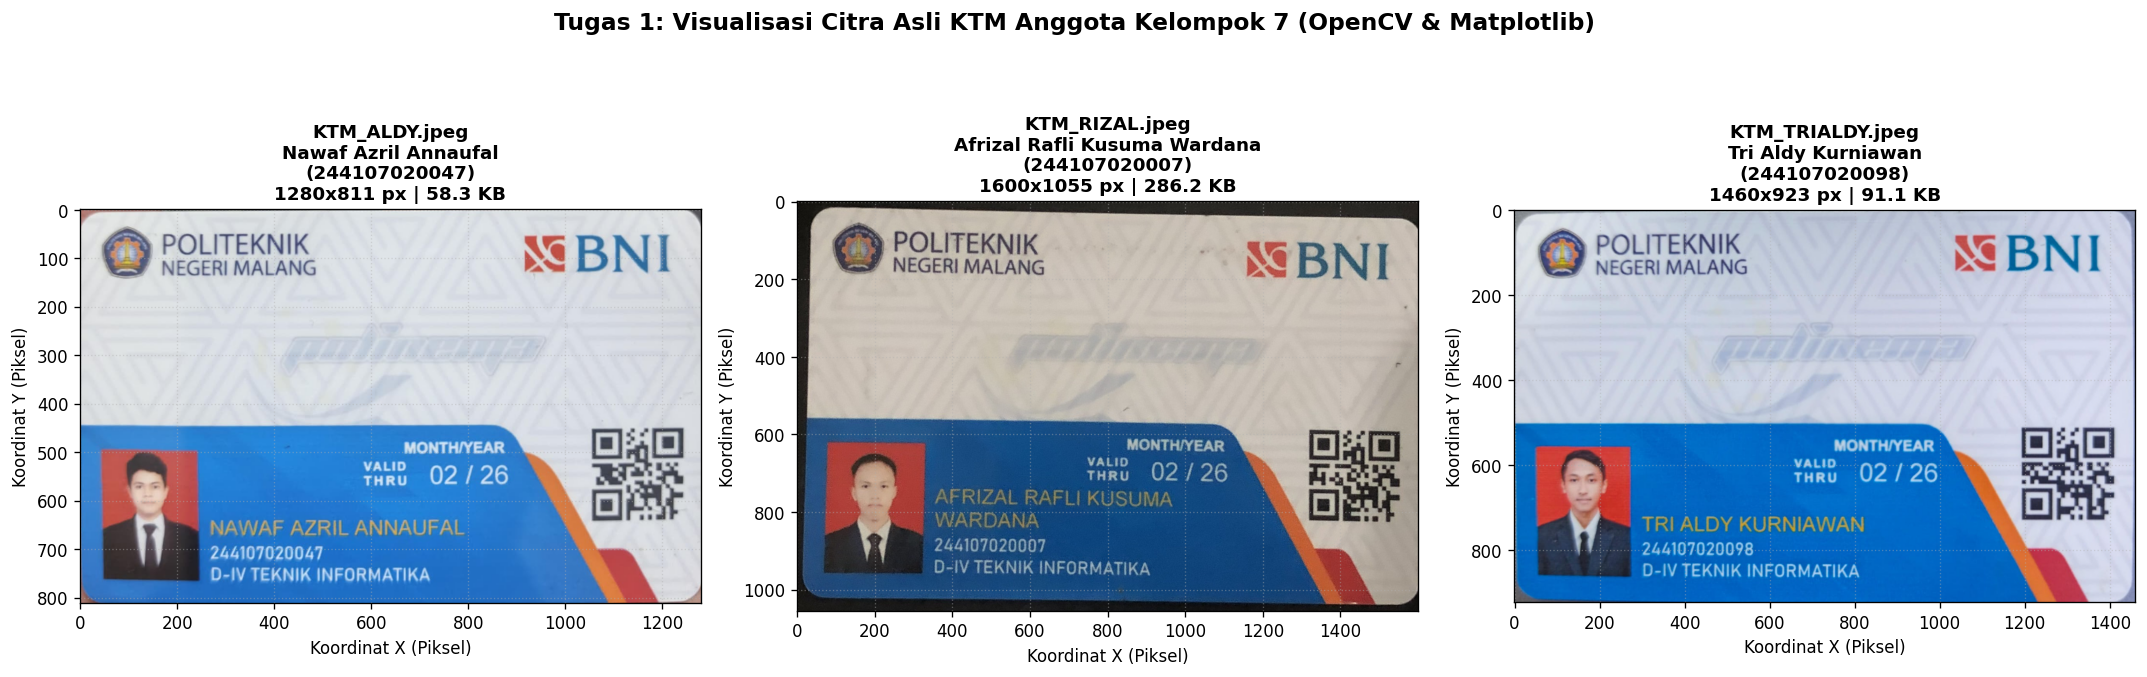

In [3]:
# Menampilkan ketiga citra asli secara berdampingan dengan Matplotlib
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

labels = [
    "Nawaf Azril Annaufal\n(244107020047)",
    "Afrizal Rafli Kusuma Wardana\n(244107020007)",
    "Tri Aldy Kurniawan\n(244107020098)"
]

for idx, (ax, info) in enumerate(zip(axes, daftar_ktm)):
    ax.imshow(info['img_rgb'])
    ax.set_title(
        f"{info['nama_file']}\n{labels[idx]}\n{info['lebar']}x{info['tinggi']} px | {info['ukuran_kb']:.1f} KB",
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Koordinat X (Piksel)')
    ax.set_ylabel('Koordinat Y (Piksel)')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.axis('on')

plt.suptitle("Tugas 1: Visualisasi Citra Asli KTM Anggota Kelompok 7 (OpenCV & Matplotlib)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Tugas 2: Menutup / Membingkai Bagian Tertentu (Kelompok 7)

Sesuai pembagian tugas untuk **Kelompok 7**, bagian yang harus ditutup/dibingkai adalah:
1. **Tulisan "Politeknik Negeri Malang"**
2. **Logo BNI**
3. **Program Studi "D-IV TEKNIK INFORMATIKA"**

### Ketentuan Implementasi:
- **Bagian tengah transparan (hollow / outline):** Menggunakan parameter `thickness > 0` (tanpa fill/isi solid), sehingga objek asli di dalam bingkai tetap terlihat jelas sebagaimana gambar referensi instruktur.
- **Kreativitas Bentuk & Warna Tiap KTM:**
  - **KTM 1 - Nawaf Azril Annaufal (`KTM_ALDY.jpeg`):**
    - *Politeknik Negeri Malang:* `cv2.rectangle` warna Royal Blue `(0, 102, 255)`, tebal 4 px.
    - *Logo BNI:* `cv2.rectangle` warna Vivid Orange `(255, 102, 0)`, tebal 4 px.
    - *D-IV Teknik Informatika:* `cv2.rectangle` warna Lime Green `(0, 230, 64)`, tebal 3 px.
  - **KTM 2 - Afrizal Rafli Kusuma Wardana (`KTM_RIZAL.jpeg`):**
    - *Politeknik Negeri Malang:* `cv2.rectangle` warna Crimson Red `(238, 43, 43)`, tebal 5 px.
    - *Logo BNI:* `cv2.ellipse` (Bentuk Elips Dinamis) warna Golden Amber `(255, 204, 0)`, tebal 5 px.
    - *D-IV Teknik Informatika:* `cv2.rectangle` warna Cyan Electric `(0, 210, 255)`, tebal 4 px.
  - **KTM 3 - Tri Aldy Kurniawan (`KTM_TRIALDY.jpeg`):**
    - *Politeknik Negeri Malang:* `cv2.rectangle` warna Amethyst Purple `(175, 40, 220)`, tebal 4 px.
    - *Logo BNI:* `cv2.ellipse` (Bentuk Elips Dinamis) warna Coral Orange `(255, 110, 30)`, tebal 4 px.
    - *D-IV Teknik Informatika:* `cv2.rectangle` warna Emerald Green `(46, 204, 113)`, tebal 4 px.


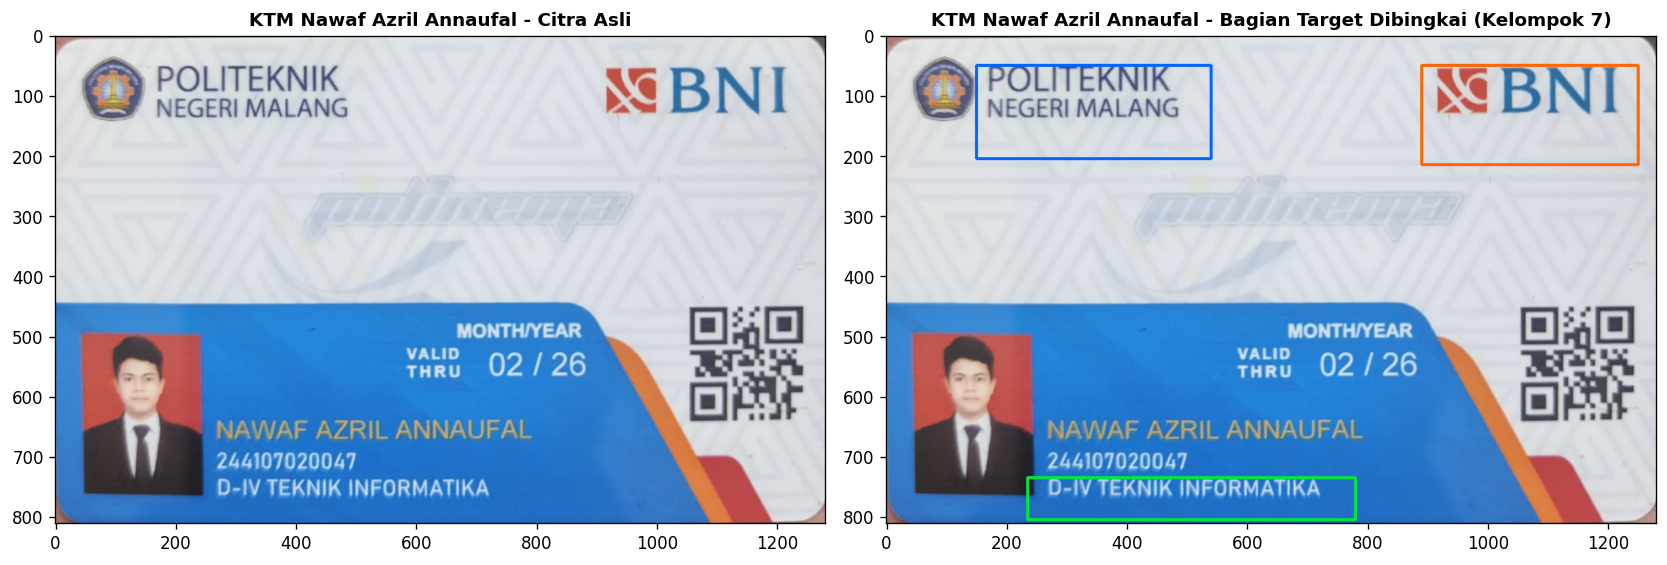

In [4]:
# =========================================================================
# 1. Pemrosesan KTM Nawaf Azril Annaufal (KTM_ALDY.jpeg)
# =========================================================================
img_aldy_masked = ktm_aldy_info['img_rgb'].copy()

# A. Tulisan Politeknik Negeri Malang (Rectangle: Royal Blue)
cv2.rectangle(img_aldy_masked, (150, 50), (540, 205), color=(0, 102, 255), thickness=4)

# B. Logo BNI (Rectangle: Vivid Orange)
cv2.rectangle(img_aldy_masked, (890, 50), (1250, 215), color=(255, 102, 0), thickness=4)

# C. Program Studi D-IV TEKNIK INFORMATIKA (Rectangle: Lime Green)
cv2.rectangle(img_aldy_masked, (235, 735), (780, 805), color=(0, 230, 64), thickness=3)

# Visualisasi Before vs After untuk KTM ALDY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(ktm_aldy_info['img_rgb'])
axes[0].set_title("KTM Nawaf Azril Annaufal - Citra Asli", fontsize=11, fontweight='bold')
axes[0].axis('on')

axes[1].imshow(img_aldy_masked)
axes[1].set_title("KTM Nawaf Azril Annaufal - Bagian Target Dibingkai (Kelompok 7)", fontsize=11, fontweight='bold')
axes[1].axis('on')

plt.tight_layout()
plt.show()


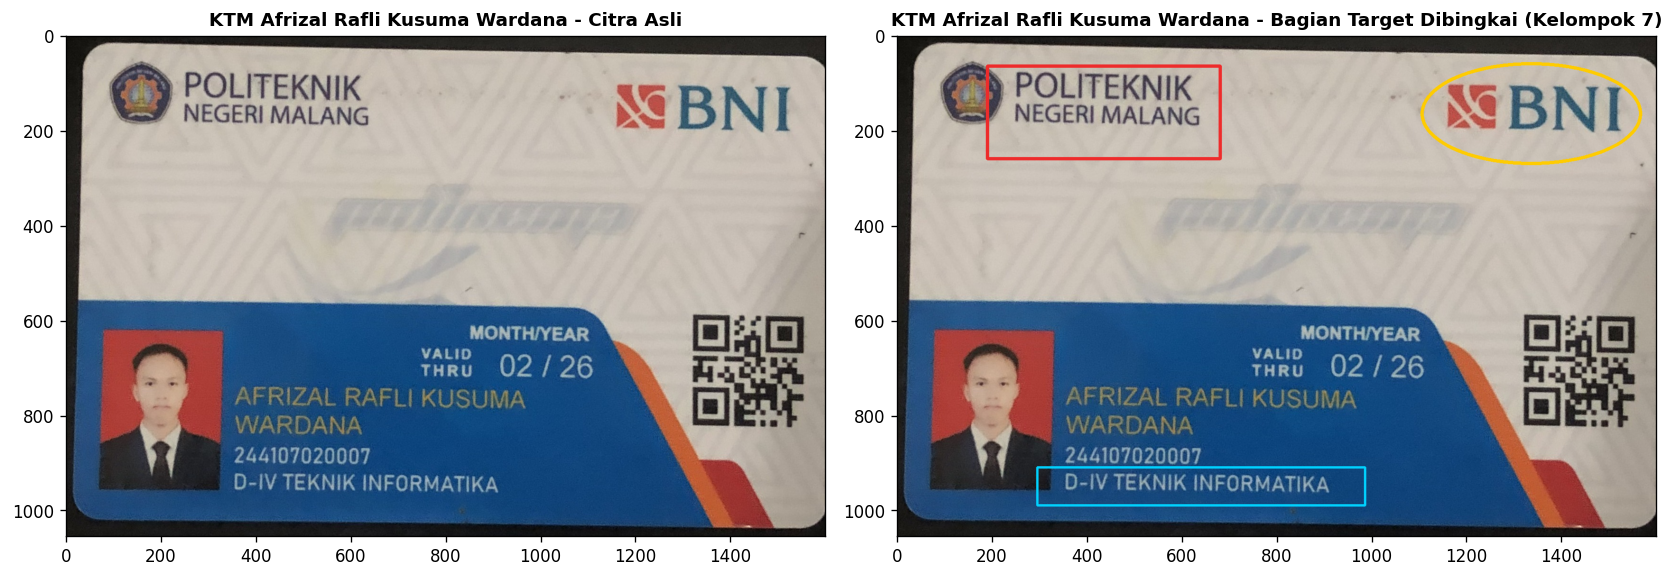

In [5]:
# =========================================================================
# 2. Pemrosesan KTM Afrizal Rafli Kusuma Wardana (KTM_RIZAL.jpeg)
# =========================================================================
img_rizal_masked = ktm_rizal_info['img_rgb'].copy()

# A. Tulisan Politeknik Negeri Malang (Rectangle: Crimson Red)
cv2.rectangle(img_rizal_masked, (190, 65), (680, 260), color=(238, 43, 43), thickness=5)

# B. Logo BNI (Ellipse: Golden Amber)
center_bni_rizal = (1335, 165)
axes_bni_rizal = (230, 105)
cv2.ellipse(img_rizal_masked, center_bni_rizal, axes_bni_rizal, 
            angle=0, startAngle=0, endAngle=360, color=(255, 204, 0), thickness=5)

# C. Program Studi D-IV TEKNIK INFORMATIKA (Rectangle: Cyan Electric)
cv2.rectangle(img_rizal_masked, (295, 910), (985, 990), color=(0, 210, 255), thickness=4)

# Visualisasi Before vs After untuk KTM RIZAL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(ktm_rizal_info['img_rgb'])
axes[0].set_title("KTM Afrizal Rafli Kusuma Wardana - Citra Asli", fontsize=11, fontweight='bold')
axes[0].axis('on')

axes[1].imshow(img_rizal_masked)
axes[1].set_title("KTM Afrizal Rafli Kusuma Wardana - Bagian Target Dibingkai (Kelompok 7)", fontsize=11, fontweight='bold')
axes[1].axis('on')

plt.tight_layout()
plt.show()


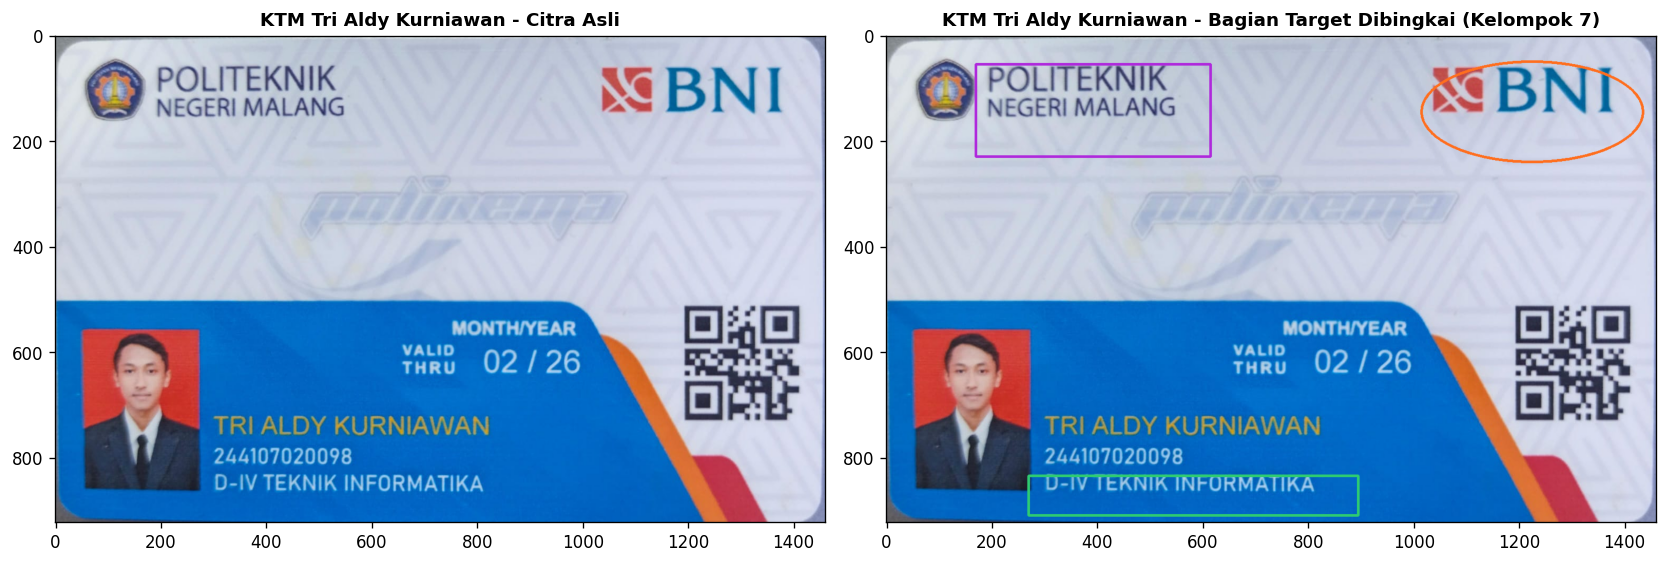

In [6]:
# =========================================================================
# 3. Pemrosesan KTM Tri Aldy Kurniawan (KTM_TRIALDY.jpeg)
# =========================================================================
img_trialdy_masked = ktm_trialdy_info['img_rgb'].copy()

# A. Tulisan Politeknik Negeri Malang (Rectangle: Purple / Magenta)
cv2.rectangle(img_trialdy_masked, (170, 55), (615, 230), color=(175, 40, 220), thickness=4)

# B. Logo BNI (Ellipse: Coral Orange)
center_bni_trialdy = (1225, 145)
axes_bni_trialdy = (210, 95)
cv2.ellipse(img_trialdy_masked, center_bni_trialdy, axes_bni_trialdy, 
            angle=0, startAngle=0, endAngle=360, color=(255, 110, 30), thickness=4)

# C. Program Studi D-IV TEKNIK INFORMATIKA (Rectangle: Emerald Green)
cv2.rectangle(img_trialdy_masked, (270, 835), (895, 910), color=(46, 204, 113), thickness=4)

# Visualisasi Before vs After untuk KTM TRIALDY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(ktm_trialdy_info['img_rgb'])
axes[0].set_title("KTM Tri Aldy Kurniawan - Citra Asli", fontsize=11, fontweight='bold')
axes[0].axis('on')

axes[1].imshow(img_trialdy_masked)
axes[1].set_title("KTM Tri Aldy Kurniawan - Bagian Target Dibingkai (Kelompok 7)", fontsize=11, fontweight='bold')
axes[1].axis('on')

plt.tight_layout()
plt.show()


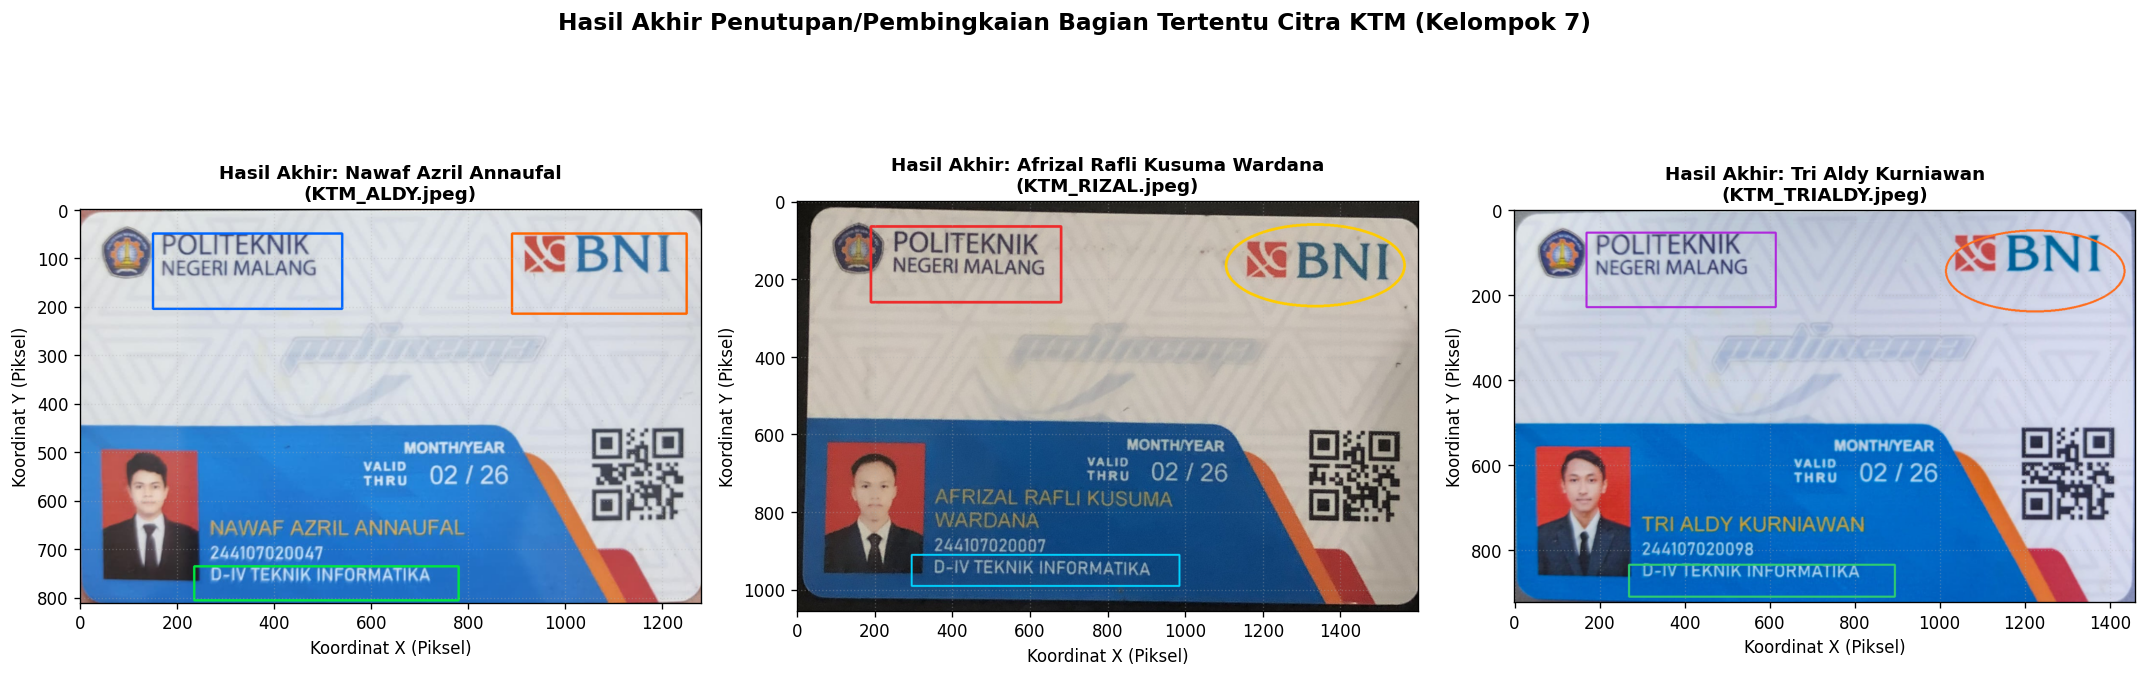

In [7]:
# Menampilkan komparasi akhir ketiga citra hasil modifikasi berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

daftar_hasil = [
    (img_aldy_masked, "Nawaf Azril Annaufal\n(KTM_ALDY.jpeg)"),
    (img_rizal_masked, "Afrizal Rafli Kusuma Wardana\n(KTM_RIZAL.jpeg)"),
    (img_trialdy_masked, "Tri Aldy Kurniawan\n(KTM_TRIALDY.jpeg)")
]

for ax, (img_res, title) in zip(axes, daftar_hasil):
    ax.imshow(img_res)
    ax.set_title(f"Hasil Akhir: {title}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Koordinat X (Piksel)')
    ax.set_ylabel('Koordinat Y (Piksel)')
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.axis('on')

plt.suptitle("Hasil Akhir Penutupan/Pembingkaian Bagian Tertentu Citra KTM (Kelompok 7)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Analisis Teknis dan Pembahasan

### 1. Perbedaan Representasi Format Warna (OpenCV BGR vs Matplotlib RGB)
- Pustaka **OpenCV** secara default membaca dan menyimpan citra dalam urutan kanal **BGR (Blue, Green, Red)** karena alasan historis kompatibilitas hardware kamera awal.
- Sementara itu, **Matplotlib** mengasumsikan citra berurutan kanal standar **RGB (Red, Green, Blue)**.
- Apabila citra BGR langsung di-render menggunakan `plt.imshow()`, warna akan mengalami *color swapping* (komponen warna merah bertukar dengan biru).
- Konversi warna menggunakan `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` wajib dilakukan untuk memastikan warna tampil akurat.

### 2. Sistem Koordinat Spasial OpenCV vs Indeks Matriks NumPy
- Fungsi geometri pada OpenCV (`cv2.rectangle`, `cv2.circle`, `cv2.ellipse`) menggunakan sistem koordinat kartesian spasial citra: **`(x, y)`** di mana:
  - $x$ merepresentasikan posisi **kolom horizontal** (dari kiri ke kanan, rentang $0 \le x < \text{lebar}$).
  - $y$ merepresentasikan posisi **baris vertikal** (dari atas ke bawah, rentang $0 \le y < \text{tinggi}$).
- Sebaliknya, ketika memanipulasi citra melalui slicing matriks NumPy secara langsung, urutan indeks yang digunakan adalah indeks baris dan kolom: **`img[baris, kolom] = img[y, x]`**.

### 3. Pengendalian Pengisian Bentuk melalui Parameter `thickness`
- Parameter `thickness` pada fungsi primitif geometri OpenCV berfungsi menentukan ketebalan dan status pengisian:
  - `thickness > 0`: Menggambar garis tepi (*outline / border*) dengan ketebalan sejumlah piksel tersebut, menyisakan area dalam tetap transparan / tidak berubah (sesuai kebutuhan penugasan ini).
  - `thickness = -1` (atau konstanta `cv2.FILLED`): Mengisi seluruh area dalam bentuk secara padat (*solid fill*).

---
## Kesimpulan
Seluruh anggota **Kelompok 7** telah berhasil:
1. Mengakses dan menampilkan citra lokal KTM (`KTM_ALDY.jpeg`, `KTM_RIZAL.jpeg`, dan `KTM_TRIALDY.jpeg`) menggunakan **OpenCV** dan **Matplotlib** secara akurat beserta ekstraksi metadata dimensi dan ukuran filenya.
2. Melakukan penutupan/pembingkaian pada 3 area yang ditugaskan khusus untuk **Kelompok 7**:
   - Tulisan **Politeknik Negeri Malang**
   - **Logo BNI**
   - Bagian **Program Studi D-IV TEKNIK INFORMATIKA**
3. Mengkreasikan variasi bentuk geometri (`cv2.rectangle` dan `cv2.ellipse`) serta palet warna estetis dengan garis outline transparan di bagian tengah, sehingga informasi target terlindungi dan teridentifikasi dengan rapi dan presisi.
